In [325]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import functions


importlib.reload(functions)

from functions import *

In [305]:
import torch 
import torch.nn as nn
import torch.nn.functional  as F

from torch import Tensor
from torchvision import transforms

import pandas as pd
import PIL.Image as Image

import kagglehub

In [306]:
path = kagglehub.dataset_download("zalando-research/fashionmnist")

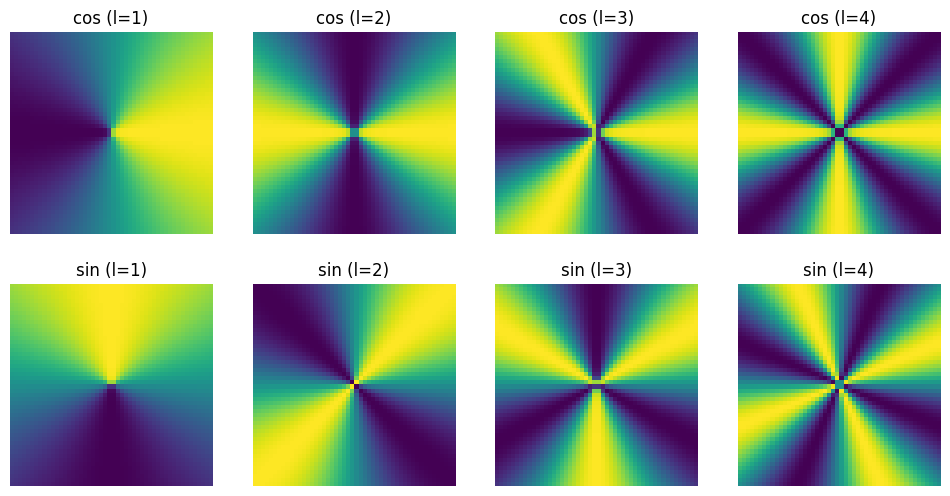

In [307]:
n = 50
basis, radius_map = functions.fourier_basis(n,4,plot = True)

In [308]:
class MLP_Radius(nn.Module):
    def __init__(self, in_features= 1, hidden_units = 8, out_features = 1, bias = False):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.hidden_units = hidden_units
        if bias:
            self.bias = nn.Parameter(torch.randn(out_features))
        else:
            self.bias = None
        
        self.layer = nn.Sequential(
            nn.Linear(self.in_features, self.hidden_units, bias = self.bias),
            nn.ReLU(),
            nn.Linear(self.hidden_units, self.out_features, bias = self.bias)
            )
    def forward(self, x):
        return self.layer(x)


F.conv2d laver convolution. skal bare give den kernel
den kernel den får er et en radialafhængig vægt ganget på hver pixel i den givne fourierbasis.
(hmm det betyde vel at vi ikke kan genbruge convolutionen til flere kernels, fordi den har ganget vægte på)

In [309]:
type(radius_map)

numpy.ndarray

torch.Size([50, 50])


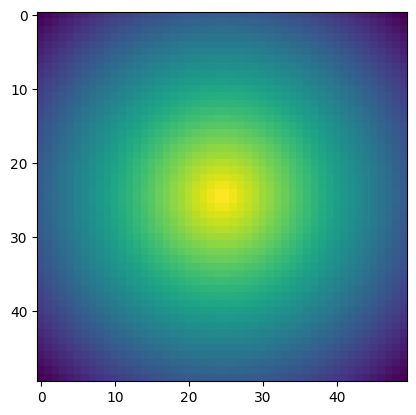

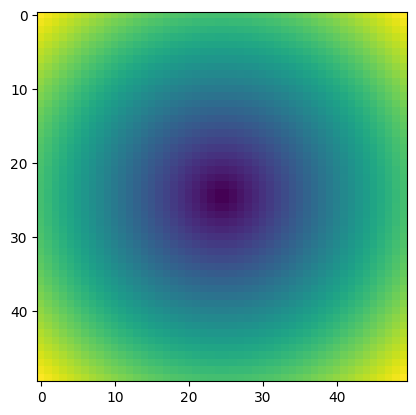

In [310]:

var = torch.tensor(radius_map/25).float()

print(var.shape)
var = var.flatten()
var = var.unsqueeze(1)

tester = MLP_Radius(hidden_units= 3, bias=True)

outputs = tester(var)
outputs = outputs.squeeze_()
outputs = outputs.reshape(50,50)
plt.imshow(outputs.detach().numpy())
plt.show()
plt.imshow(radius_map)
# print('outputs', outputs)
# radius_map

In [311]:
class LiftingLayer(nn.Module):
    def __init__(self, in_features, out_features, kernel_size, l,  bias=True):
        super(LiftingLayer, self).__init__()
        self.MLP_Radius_ = MLP_Radius()
        # Define learnable parameters
        self.k_size = kernel_size
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.l = l
        
        
        if bias:
            self.bias = nn.Parameter(torch.randn(out_features))
        else:
            self.bias = None

    def forward(self, x):
        # x shape: (batch_size, in_features)
        #fourier folder
        basis, radius_map = fourier_basis(kernel_size = self.k_size, l = self.l)
        radius_map = torch.tensor(radius_map).float().flatten().unsqueeze(1)
        self.MLP_Radius_(radius_map).squeeze_().reshape(self.k_size,self.k_size)



        out = x @ w.t()  # matrix multiplication
        
        if self.bias is not None:
            out += self.bias
        
        return out

In [326]:
basis, radius_map = fourier_basis(kernel_size =10, l = 10)

(basis).shape

torch.Size([11, 10, 10])

# MNIST


In [ ]:
#Laver vores MNIST image
RESIZE_SIZE = 280

df = pd.read_csv(path + '/fashion-mnist_train.csv')
row1 = df.iloc[0, 1:].values
pixel = row1.reshape(28,28).astype(np.uint8)

img = Image.fromarray(pixel)
print(img.resize((280, 280), Image.NEAREST))

transform = transforms.ToTensor()

img = img.resize((RESIZE_SIZE, RESIZE_SIZE), Image.NEAREST)

image = transform(img)


<PIL.Image.Image image mode=L size=280x280 at 0x1678D3080>


In [ ]:
image.unsqueeze_(1)
image.shape

torch.Size([1, 1, 280, 280])

## Convolutions

In [ ]:
temp = basis[-1].clone()
temp = temp.float()
temp.unsqueeze_(0)
temp.shape


torch.Size([1, 1, 50, 50])

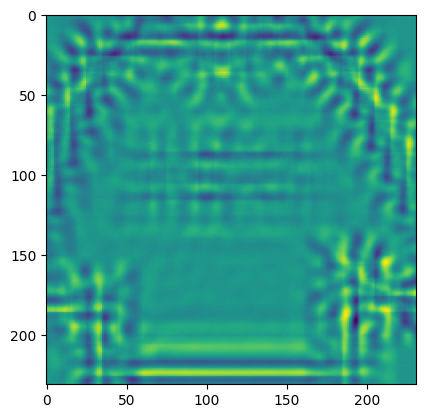

In [ ]:
output = F.conv2d(input=image, weight=temp)

output.squeeze_()
output.shape
plt.imshow(output)

In [ ]:
?F.conv2

Object `F.conv2` not found.
